# Clipping with Planes & Boxes

Clip/cut any dataset using using planes or boxes.


In [1]:
import pyvista as pv
from pyvista import examples

c:\Users\Usuario\anaconda3\envs\VAD\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Clip with Plane

Clip any dataset by a user defined plane using the
`pyvista.DataSetFilters.clip`{.interpreted-text role="func"} filter


In [2]:
dataset = examples.download_bunny_coarse()
dataset

PolyData (0x1f71f3d2800)
  N Cells:    1000
  N Points:   872
  N Strips:   0
  X Bounds:   -1.316e-01, 1.802e-01
  Y Bounds:   -1.205e-01, 1.877e-01
  Z Bounds:   -1.430e-01, 9.851e-02
  N Arrays:   1

In [3]:
help(dataset.clip)

Help on method clip in module pyvista.core.filters.data_object:

clip(
    normal: 'VectorLike[float] | _NormalsLiteral | None' = None,
    origin: 'VectorLike[float] | None' = None,
    invert: 'bool' = True,
    value: 'float' = 0.0,
    inplace: 'bool' = False,
    return_clipped: 'bool' = False,
    progress_bar: 'bool' = False,
    crinkle: 'bool' = False,
    plane: 'PolyData | None' = None
) method of pyvista.core.pointset.PolyData instance
    Clip a dataset by a plane by specifying the origin and normal.

    The origin and normal may be set explicitly or implicitly using a
    :func:`~pyvista.Plane`.

    If no parameters are given, the clip will occur in the center
    of the dataset along the x-axis.

    Parameters
    ----------
    normal : VectorLike[float] | str, optional
        Length-3 vector for the normal vector direction. Can also
        be specified as a string conventional direction such as
        ``'x'`` for ``(1, 0, 0)`` or ``'-x'`` for ``(-1, 0, 0)``, etc.

Perform a clip with a Y axis normal


In [4]:
clipped = dataset.clip(normal = (1,0,0),
                       origin = (0,0,0))
clipped

PolyData (0x1f71f7cf820)
  N Cells:    641
  N Points:   367
  N Strips:   0
  X Bounds:   -1.316e-01, 4.337e-19
  Y Bounds:   -1.205e-01, 1.761e-01
  Z Bounds:   -1.430e-01, 8.721e-02
  N Arrays:   1

Plot the result.


C:\Users\Usuario\AppData\Local\Temp\ipykernel_3880\1073913496.py:6: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  pl.show()


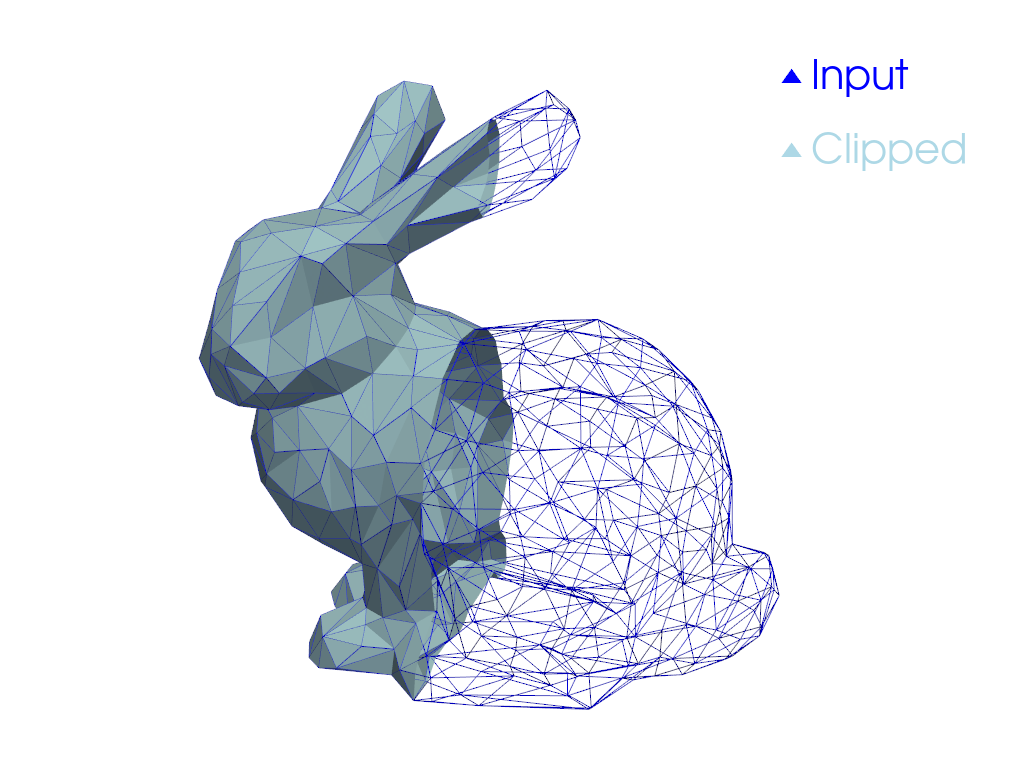

In [5]:
pl = pv.Plotter()
pl.add_mesh(dataset, style="wireframe", color="blue", label="Input")
pl.add_mesh(clipped, label="Clipped")
pl.add_legend()
pl.camera_position = [(0.24, 0.32, 0.7), (0.02, 0.03, -0.02), (-0.12, 0.93, -0.34)]
pl.show()

# Clip with Bounds

Clip any dataset by a set of XYZ bounds using the
`pyvista.DataSetFilters.clip_box`{.interpreted-text role="func"} filter.

First, download an example dataset.


In [6]:
dataset = examples.download_office()

In [7]:
help(dataset.clip_box)

Help on method clip_box in module pyvista.core.filters.data_object:

clip_box(
    bounds: 'float | VectorLike[float] | PolyData | None' = None,
    invert: 'bool' = True,
    factor: 'float' = 0.35,
    progress_bar: 'bool' = False,
    merge_points: 'bool' = True,
    crinkle: 'bool' = False
) method of pyvista.core.pointset.StructuredGrid instance
    Clip a dataset by a bounding box defined by the bounds.

    If no bounds are given, a corner of the dataset bounds will be removed.

    Parameters
    ----------
    bounds : sequence[float], optional
        Length 6 sequence of floats: ``(x_min, x_max, y_min, y_max, z_min, z_max)``.
        Length 3 sequence of floats: distances from the min coordinate of
        of the input mesh. Single float value: uniform distance from the
        min coordinate. Length 12 sequence of length 3 sequence of floats:
        a plane collection (normal, center, ...).
        :class:`pyvista.PolyData`: if a poly mesh is passed that represents
       

Clip the dataset with a bounding box defined by the values in `bounds`
`(xmin, xmax, ymin, ymax, zmin, zmax)`


In [8]:
bounds = [2, 4.5, 2, 4.5, 1, 3]
clipped = dataset.clip_box(bounds=bounds)
clipped

UnstructuredGrid (0x1f7a90d0be0)
  N Cells:    38690
  N Points:   8118
  X Bounds:   1.000e-02, 4.500e+00
  Y Bounds:   1.000e-02, 4.500e+00
  Z Bounds:   1.000e-02, 2.500e+00
  N Arrays:   2

Plot the original dataset and the clipped one.


C:\Users\Usuario\AppData\Local\Temp\ipykernel_3880\1828208607.py:5: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  pl.show()


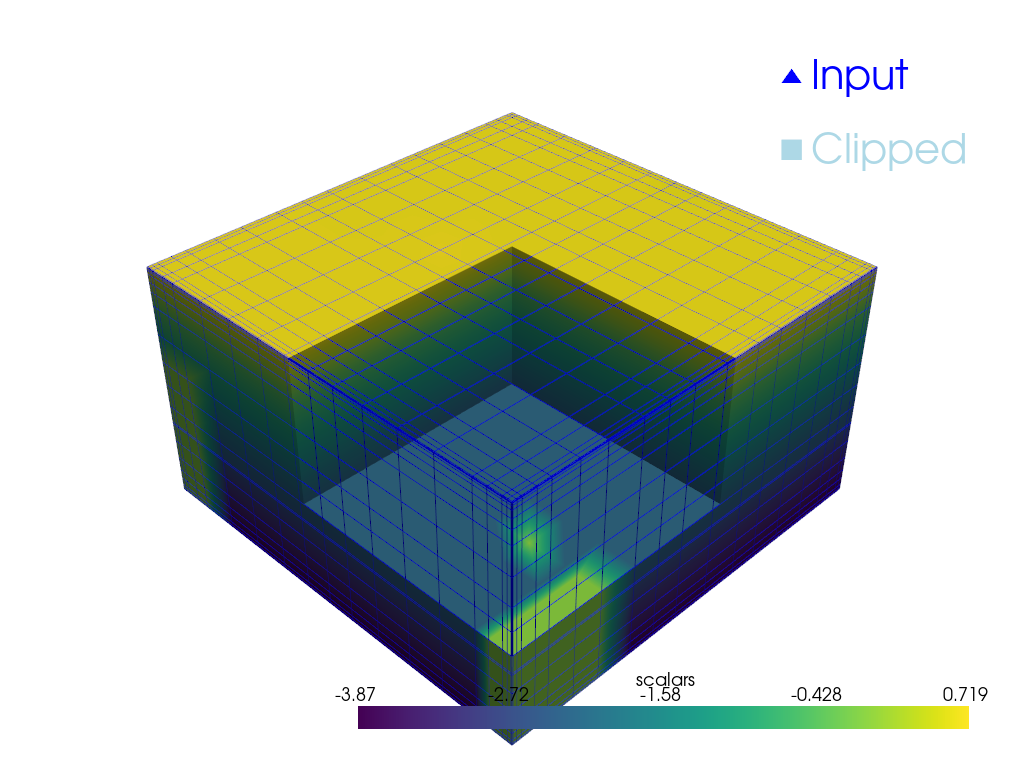

In [9]:
pl = pv.Plotter()
pl.add_mesh(dataset, style="wireframe", color="blue", label="Input")
pl.add_mesh(clipped, label="Clipped")
pl.add_legend()
pl.show()

# Clip with Rotated Box

Clip any dataset by an arbitrarily rotated solid box using the
`pyvista.DataSetFilters.clip_box`{.interpreted-text role="func"} filter.


C:\Users\Usuario\AppData\Local\Temp\ipykernel_3880\799170228.py:10: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  pl.show()


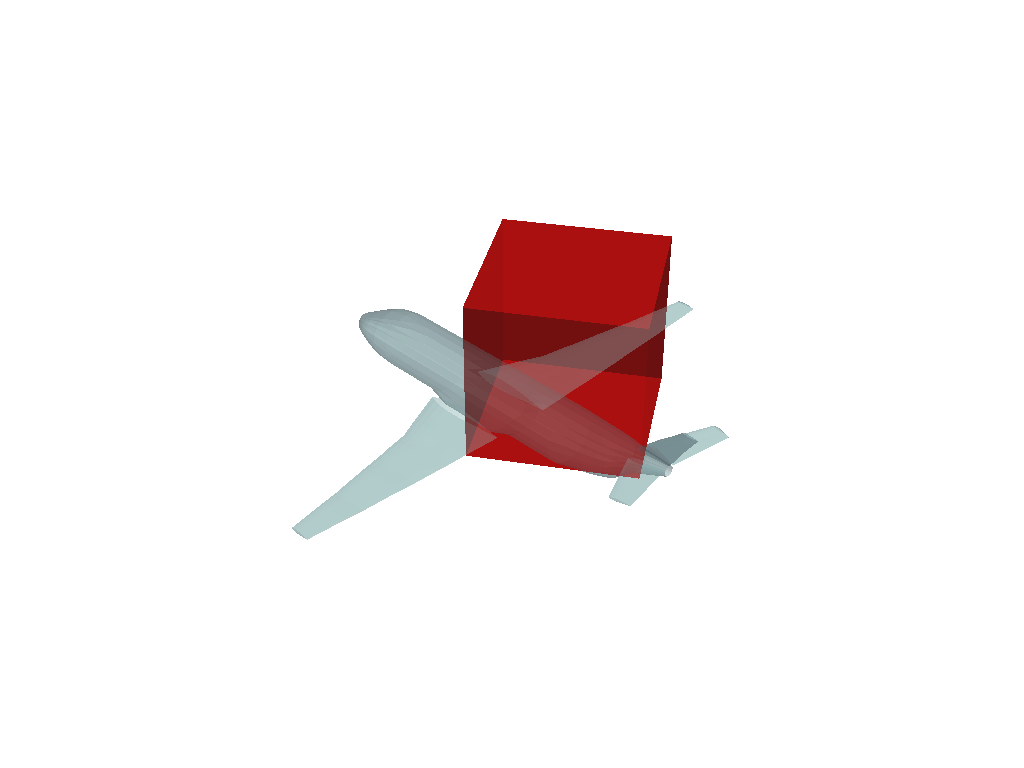

In [10]:
mesh = examples.load_airplane()

# Use `pv.Box()` or `pv.Cube()` to create a region of interest
roi = pv.Cube(center=(0.9e3, 0.2e3, mesh.center[2]), x_length=500, y_length=500, z_length=500)
roi.rotate_z(33, inplace=True)

pl = pv.Plotter()
pl.add_mesh(roi, opacity=0.75, color="red")
pl.add_mesh(mesh, opacity=0.5)
pl.show()

Run the box clipping algorithm with the defined box geometry.


C:\Users\Usuario\AppData\Local\Temp\ipykernel_3880\4158480730.py:11: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  pl.show()


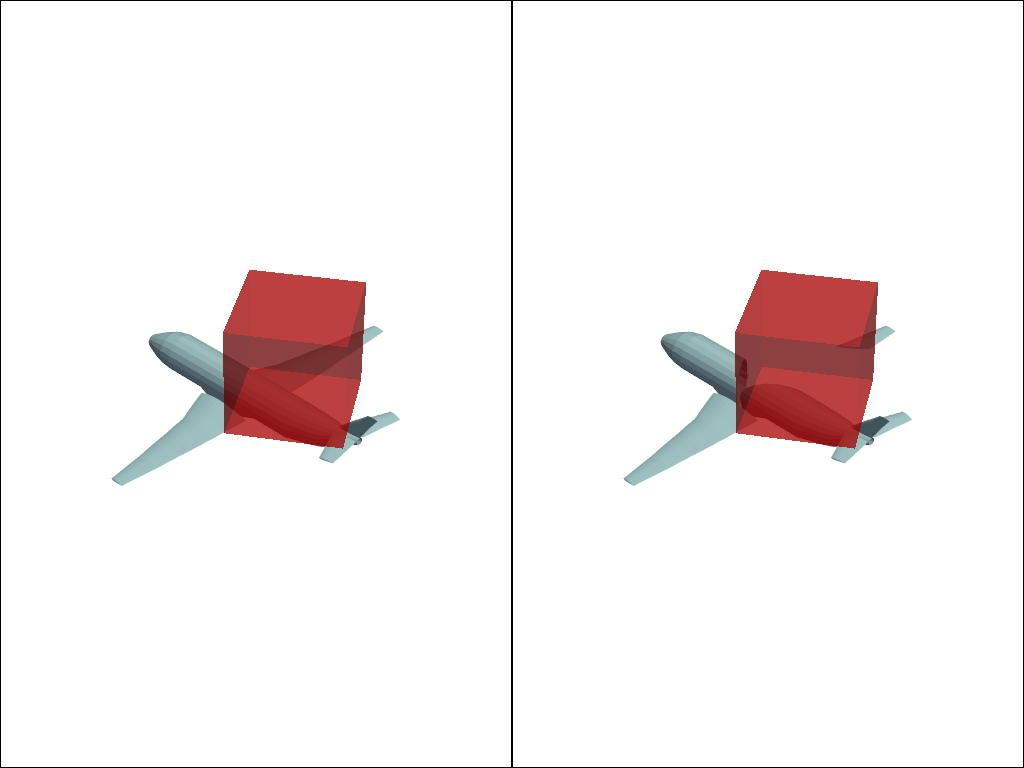

In [14]:
extracted = mesh.clip_box(roi)

pl = pv.Plotter(shape=(1, 2))
pl.add_mesh(roi, opacity=0.5, color="red")
pl.add_mesh(mesh)
pl.subplot(0, 1)
pl.add_mesh(extracted)
pl.add_mesh(roi, opacity=0.5, color="red")
pl.link_views()
pl.view_isometric()
pl.show()

# Crinkled Clipping

Crinkled clipping is useful if you don\'t want the clip filter to truly
clip cells on the boundary, but want to preserve the input cell
structure and to pass the entire cell on through the boundary.

This option is available for
`pyvista.DataSetFilters.clip`{.interpreted-text role="func"},
`pyvista.DataSetFilters.clip_box`{.interpreted-text role="func"}, and
`pyvista.DataSetFilters.clip_sruface`{.interpreted-text role="func"},
but not available when clipping by scalar in
`pyvista.DataSetFilters.clip_scalar`{.interpreted-text role="func"}.


In [15]:
# Input mesh
mesh = pv.Wavelet()

Define clipping plane


In [16]:
normal = (1, 1, 1)
plane = pv.Plane(i_size=30, j_size=30, direction=normal)

Perform a standard clip


In [17]:
clipped = mesh.clip(normal=normal)

Perform a crinkled clip to compare


In [19]:
crinkled = mesh.clip(crinkle=True, normal=normal)

Plot comparison


C:\Users\Usuario\AppData\Local\Temp\ipykernel_3880\609863535.py:8: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  pl.show()


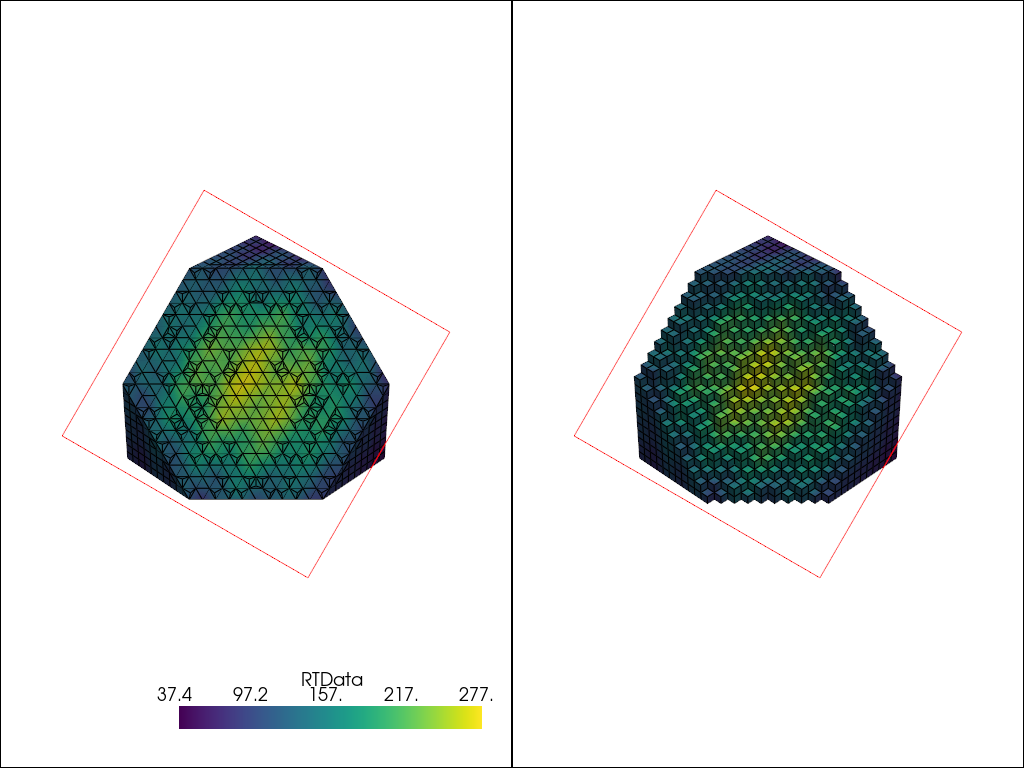

In [20]:
pl = pv.Plotter(shape=(1, 2))
pl.add_mesh(clipped, show_edges=True)
pl.add_mesh(plane.extract_feature_edges(), color="r")
pl.subplot(0, 1)
pl.add_mesh(crinkled, show_edges=True)
pl.add_mesh(plane.extract_feature_edges(), color="r")
pl.link_views()
pl.show()

```{=html}
<center>
  <a target="_blank" href="https://colab.research.google.com/github/pyvista/pyvista-tutorial/blob/gh-pages/notebooks/tutorial/04_filters/exercises/b_clipping.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/ width="150px">
  </a>
</center>
```
